# Heat Diffusion: Dataset Generation, Visualization, Training & Benchmarking

This notebook demonstrates:
1. Generating random graphs via a constant graphon.
2. Simulating heat diffusion to get initial and final temperatures.
3. Visualizing a sample temperature trajectory.
4. Training a GCN to predict steady-state temperatures.
5. Benchmarking MSE on a held-out set.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from logic.graphon_generator import generate_constant_graphon, interp_graphon, sample_graph
from simulator.heat_simulator import simulate_heat_diffusion
from model.models import HeatGCN
import torch
from torch_geometric.data import Data, DataLoader
import torch.nn.functional as F


## 1. Dataset Preparation
We sample `num_graphs` random graphs from a constant graphon (p=0.1), simulate heat diffusion for each, and collect `(graph, init_temps, final_temps)` pairs.

In [3]:
# Parameters
num_graphs = 200
num_nodes = 50
steps = 50
alpha = 0.1
# Build graphon function
W = generate_constant_graphon(p=0.1, resolution=200)
graphon_fn = interp_graphon(W)
# Prepare lists
dataset = []
for _ in range(num_graphs):
    G = sample_graph(graphon_fn, num_nodes)
    init = np.random.rand(num_nodes)
    traj = simulate_heat_diffusion(G, init, alpha, steps)  # shape (steps+1, N)
    final = traj[-1]  # steady-state approx
    # Build PyG Data object
    edge_index = torch.tensor(list(G.edges())).t().contiguous()
    # undirected: add reversed edges
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    data = Data(x=torch.from_numpy(init).float().unsqueeze(1),
                edge_index=edge_index,
                y=torch.from_numpy(final).float())
    dataset.append(data)
# Split train/val
split = int(0.8 * num_graphs)
train_set = dataset[:split]
val_set = dataset[split:]
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16)


c:\Users\rapon\AppData\Local\Programs\Python\Python39\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


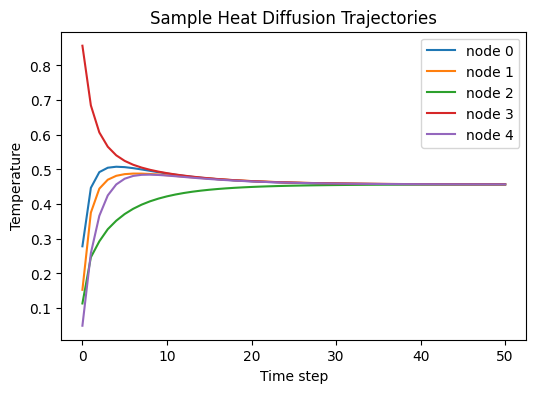

In [4]:
# Visualize one trajectory
G0 = sample_graph(graphon_fn, num_nodes)
init0 = np.random.rand(num_nodes)
traj0 = simulate_heat_diffusion(G0, init0, alpha, steps)
plt.figure(figsize=(6,4))
for node in range(5):  # plot first 5 nodes
    plt.plot(traj0[:, node], label=f'node {node}')
plt.xlabel('Time step')
plt.ylabel('Temperature')
plt.title('Sample Heat Diffusion Trajectories')
plt.legend()
plt.show()

## 2. Model, Loss & Optimizer

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeatGCN(in_channels=1, hidden_channels=32, num_layers=3, dropout=0.1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = F.mse_loss


## 3. Training Loop

In [6]:
epochs = 20
train_losses, val_losses = [], []
for epoch in range(1, epochs+1):
    model.train()
    total_train = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)  # (batch*num_nodes,)
        loss = loss_fn(out, batch.y)
        loss.backward()
        optimizer.step()
        total_train += loss.item()
    avg_train = total_train / len(train_loader)
    train_losses.append(avg_train)
    model.eval()
    total_val = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index)
            total_val += loss_fn(pred, batch.y).item()
    avg_val = total_val / len(val_loader)
    val_losses.append(avg_val)
    print(f'Epoch {epoch:02d} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')


Epoch 01 | Train Loss: 0.1943 | Val Loss: 0.1250
Epoch 02 | Train Loss: 0.0853 | Val Loss: 0.0415
Epoch 03 | Train Loss: 0.0240 | Val Loss: 0.0083
Epoch 04 | Train Loss: 0.0078 | Val Loss: 0.0074
Epoch 05 | Train Loss: 0.0090 | Val Loss: 0.0077
Epoch 06 | Train Loss: 0.0079 | Val Loss: 0.0060
Epoch 07 | Train Loss: 0.0068 | Val Loss: 0.0060
Epoch 08 | Train Loss: 0.0070 | Val Loss: 0.0060
Epoch 09 | Train Loss: 0.0069 | Val Loss: 0.0059
Epoch 10 | Train Loss: 0.0068 | Val Loss: 0.0059
Epoch 11 | Train Loss: 0.0067 | Val Loss: 0.0059
Epoch 12 | Train Loss: 0.0067 | Val Loss: 0.0058
Epoch 13 | Train Loss: 0.0068 | Val Loss: 0.0058
Epoch 14 | Train Loss: 0.0066 | Val Loss: 0.0058
Epoch 15 | Train Loss: 0.0068 | Val Loss: 0.0058
Epoch 16 | Train Loss: 0.0067 | Val Loss: 0.0058
Epoch 17 | Train Loss: 0.0067 | Val Loss: 0.0057
Epoch 18 | Train Loss: 0.0066 | Val Loss: 0.0057
Epoch 19 | Train Loss: 0.0066 | Val Loss: 0.0057
Epoch 20 | Train Loss: 0.0067 | Val Loss: 0.0057


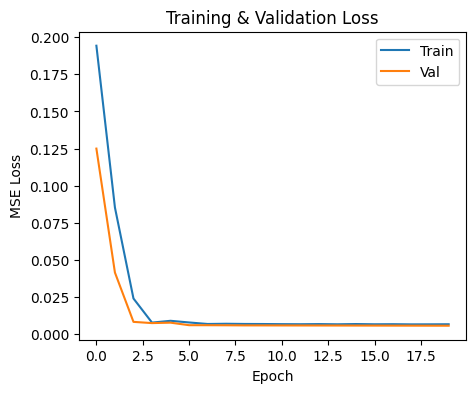

In [7]:
# Plot loss curves
plt.figure(figsize=(5,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()

## 4. Benchmark on Held-out Set

In [8]:
# Compute final MSE on validation
model.eval()
mse = 0.0
count = 0
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index)
        mse += F.mse_loss(pred, batch.y, reduction='sum').item()
        count += batch.num_nodes
mse /= count
print(f'Held-out MSE: {mse:.4f}')


Held-out MSE: 0.0057
